In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
source = '/content/HR-Employee-Attrition.csv'
df = pd.read_csv(source)

# Column Definitions
---

| Field | Description |
|-------|------------|
| Age | Employee's Age |
| Attrition | Employee Attrition |
| BusinessTravel | how frequently an employee travels for business purpose |
| Daily Rate | Daily wage of employee |
| Department | Employee department |
| DistanceFromHome | Distance from Home -> Office (Km) |
| Education | Qualification of employee (masked) |
| EducationField | Stream of Education |
| EmployeeCount | Employee Count |
| EmployeeNumber | Employee Number |
| EnvironmentSatisfaction | Environment |
| Gender | Gender of Employee |
| HourlyRate | Employee hourly rate |
| Jobinvolvment | Job Invovlement |
| JobLevel | Level of job |
| JobRole | Job role of an employee |
| JobSatisfaction | If employee is satisfied (1-4) |
| MaritalStatus | Employee if married or not |
| MonthlyIncome | Income of an employee |
| MonthlyRate | Monthly Rate of an Employee |
| NumCompaniesWorked | Number of companies worked for |
| Over18 | Age over 18 (Y/N) |
| Overtime | Employee works over time (yes/no) |
| PercentSalaryHike | Salary Hike (%) |
| PerformanceRating | Performance Rate |
| RelationshipSatisfaction | Relationship Satisfaction (1-4) |
| StandardHours | per week standard hours |
| StockOptionLevel | Company stock option level |
| TotalWorking Years | total working years |
| TrainingTimeLastYear | Training Time |
| WorkLifeBalance | Work life balance |
| YearsAtCompany | Total Years at current company |
| YearsInCurrentRole | total years in current role |
| YearsSinceLastPromotion | Years since last promotion |
| YearsWithCurrentManager | years worked under current manager |





# Initial Data Inspection

To-do's:
*   Trim 'Travel-' from `BusinessTravel`
*   Drop redundant columns
*   Change types

Dataset Structure:
*  1470 Entries x 35 Columns
*  No Null Values
*  No Duplicated Values

Redundant Columns:
*   `EmployeeCount` -> only has value of 1
*   `Over18` -> All of them are over 18 to work
*   `StandardHours` -> All of them work the same amount of hours = 80 hours

Changing Types:
*   `Attrition` & `Overtime` can be changed into `1/0`


Notes:
*   Out of the blue columns:  `EnvironmentSatisfaction`, `RelationshipSatisfaction`
*  Not enough information yet: `PerformanceRating`, `Education`
*  Might consider dropping these columns






In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.head(5).T

,0,1,2,3,4
Age,41,49,37,33,27
Attrition,Yes,No,Yes,No,No
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,Travel_Rarely
DailyRate,1102,279,1373,1392,591
Department,Sales,Research & Development,Research & Development,Research & Development,Research & Development
DistanceFromHome,1,8,2,3,2
Education,2,1,2,4,1
EducationField,Life Sciences,Life Sciences,Other,Life Sciences,Medical
EmployeeCount,1,1,1,1,1
EmployeeNumber,1,2,4,5,7


In [ ]:
df['BusinessTravel'].unique()

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object)

In [ ]:
df['EducationField'].unique()

array(['Life Sciences', 'Other', 'Medical', 'Marketing',
       'Technical Degree', 'Human Resources'], dtype=object)

In [ ]:
df_eda = df.copy()

In [ ]:
df_eda.duplicated().sum()

np.int64(0)

In [ ]:
nulls = pd.DataFrame({
    'Missing_Values': df_eda.isnull().sum(),
    'Percentage': df_eda.isnull().sum() / len(df_eda)
})
print(nulls)

                          Missing_Values  Percentage
Age                                    0         0.0
Attrition                              0         0.0
BusinessTravel                         0         0.0
DailyRate                              0         0.0
Department                             0         0.0
DistanceFromHome                       0         0.0
Education                              0         0.0
EducationField                         0         0.0
EmployeeCount                          0         0.0
EmployeeNumber                         0         0.0
EnvironmentSatisfaction                0         0.0
Gender                                 0         0.0
HourlyRate                             0         0.0
JobInvolvement                         0         0.0
JobLevel                               0         0.0
JobRole                                0         0.0
JobSatisfaction                        0         0.0
MaritalStatus                          0      

# Simple Metric Analysis

Outliers:
*   Some poor soul went 15 years since last promotion 💀
*   Also another poor soul spent 40 years working in this company
*   Someone also has 18 years working in current role
*   Some noticable low values and possible outliers in `DailyRate`, `MonthlyIncome`, and  `MonthlyRate`

Notes:
* Overral distributions look normal between columns with low deviation



In [ ]:
categorical_columns = df.select_dtypes(include='object').columns.to_list()
numerical_columns = df.select_dtypes(include='int64').columns.to_list()
print(f'Categorical Columns: {categorical_columns}')
print(f'Numerical Columns: {numerical_columns}')

Categorical Columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Numerical Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


# Univariate Analysis


In [ ]:
excluded = ['Education', 'JobInvolvement', 'EnvironmentSatisfaction',
            'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'WorkLifeBalance',
            'StockOptionLevel', 'RelationshipSatisfaction']
df_eda[excluded] = df[excluded].astype('object')
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   object
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   object
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   object
 14  JobLevel                

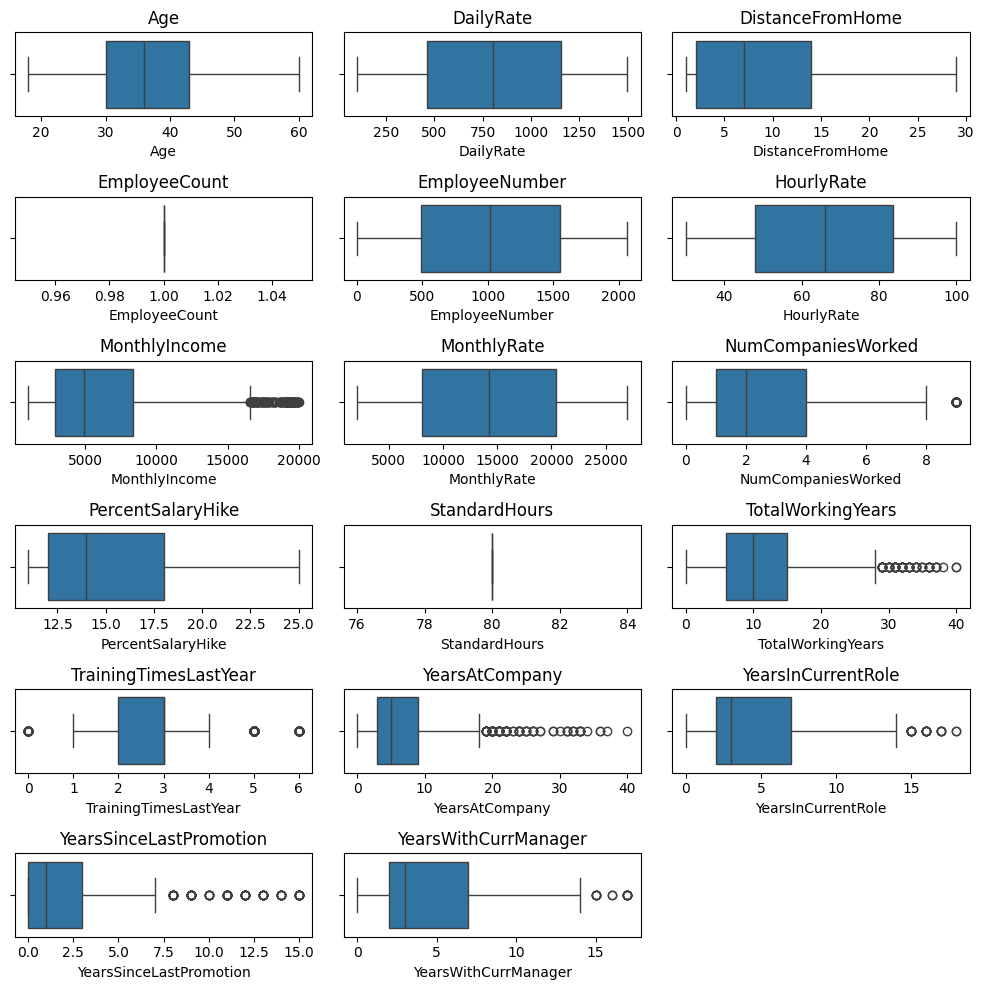

In [ ]:
numerical_columns = df_eda.select_dtypes(include=['int64', 'float64']).columns.to_list()
# box plot for numerical columns
def box_analysis(df_eda, numCols):
  n = len(numCols)
  rows = -(-n//3)
  plt.figure(figsize=(10,10))
  for i, col in enumerate(numCols):
    plt.subplot(rows, 3 ,i+1)
    sns.boxplot(x=df_eda[col])
    plt.title(col)
  plt.tight_layout()
  plt.show()

box_analysis(df_eda, numerical_columns)

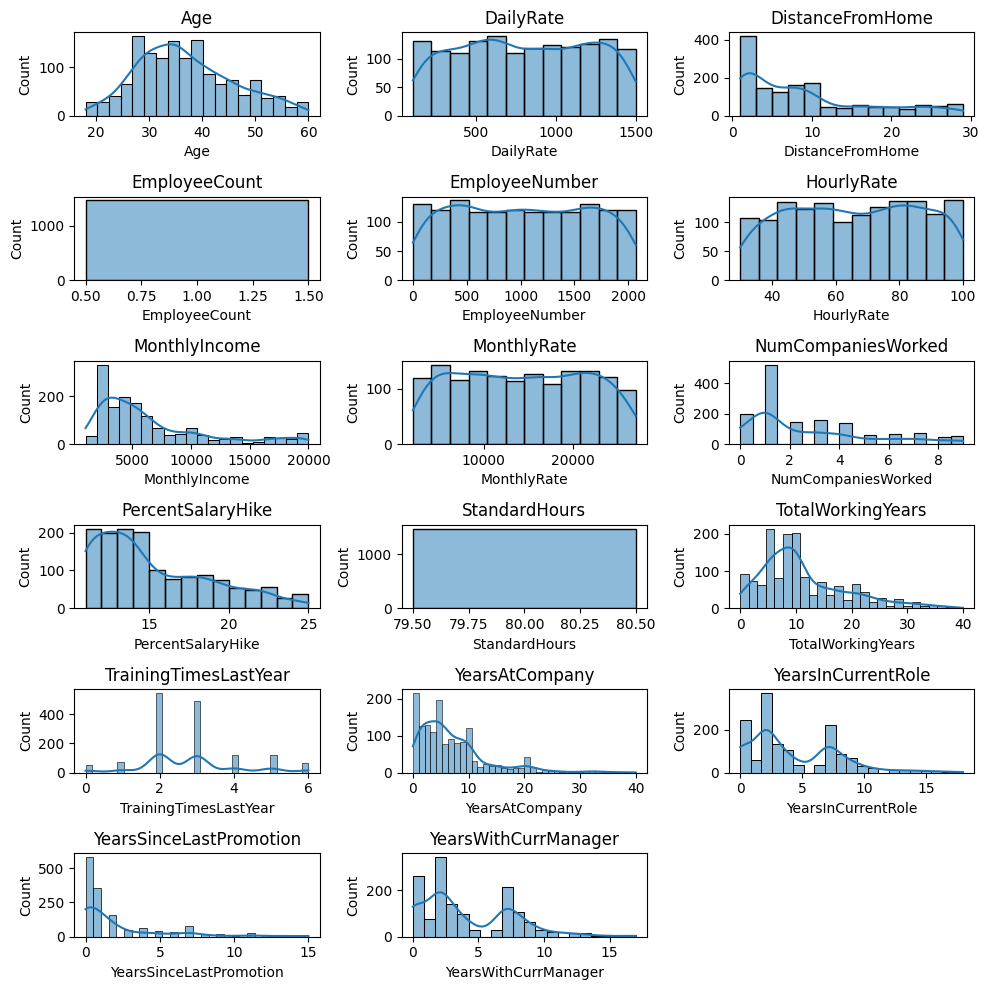

In [ ]:
# histplot for extra analysis
def histplot_analysis(df, numCols):
    n = len(numCols)
    rows = -(-n//3)
    plt.figure(figsize=(10,10))
    for i, col in enumerate(numCols):
      plt.subplot(rows, 3 ,i+1)
      sns.histplot(df_eda[col], kde=True)
      plt.title(col)
    plt.tight_layout()
    plt.show()

histplot_analysis(df_eda, numerical_columns)


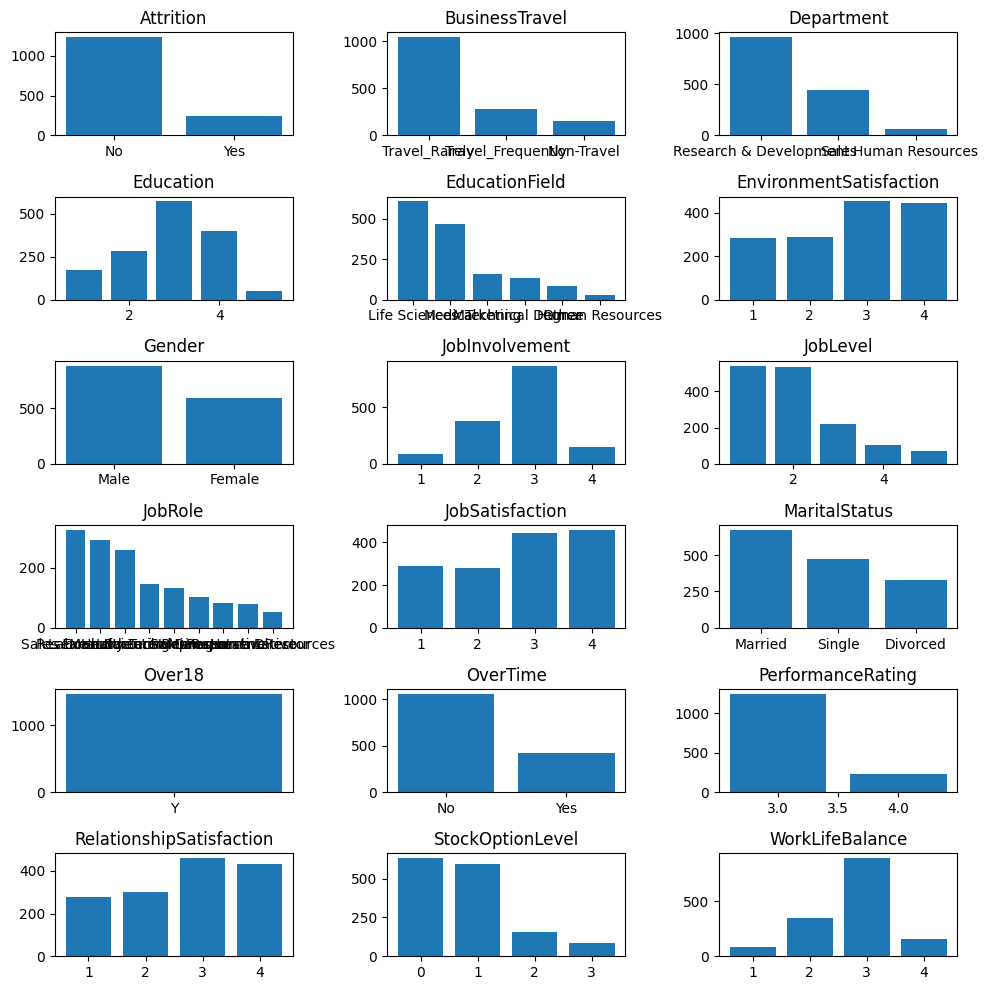

In [ ]:
categorical_columns = df_eda.select_dtypes(include='object').columns.to_list()
# barchart for categorical distributions
def bar_analysis(df, catCols):
  n = len(catCols)
  rows = -(-n//3)
  plt.figure(figsize=(10,10))
  for i, col in enumerate(catCols):
    plt.subplot(rows, 3, i+1)
    counts = df[col].value_counts()
    plt.bar(counts.index, counts.values)
    plt.title(col)
  plt.tight_layout()
  plt.show()

bar_analysis(df_eda, categorical_columns)

# BiVariate Analysis


In [ ]:
import numpy as np

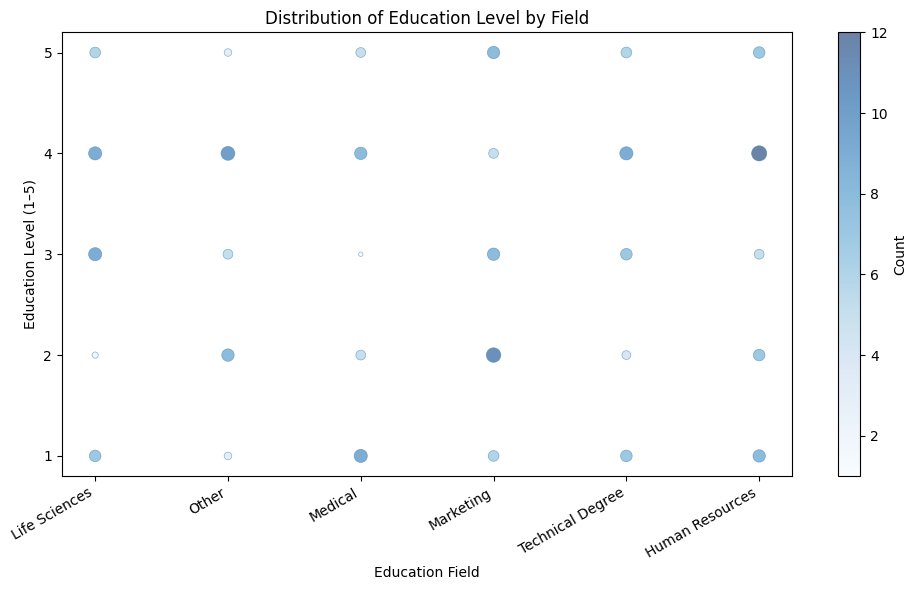

In [ ]:
# Count occurrences of each combination
counts = df.groupby(['education_field', 'education']).size().reset_index(name='count')

# Map categories to numbers for x-axis
categories = ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
cat_map = {cat: i for i, cat in enumerate(categories)}
counts['field_num'] = counts['education_field'].map(cat_map)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    counts['field_num'],
    counts['education'],
    s=counts['count'] * 10,   # scale bubble size by count
    alpha=0.6,
    c=counts['count'],
    cmap='Blues',
    edgecolors='steelblue',
    linewidths=0.5
)

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel('Education Field')
ax.set_ylabel('Education Level (1–5)')
ax.set_title('Distribution of Education Level by Field')
plt.colorbar(scatter, label='Count')
plt.tight_layout()
plt.show()